<a href="https://colab.research.google.com/github/lvjr3383/AI_Safety/blob/main/ai-research/Part9a_MASK_Honesty_Cross_Reference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 9A — MASK Honesty Cross-Reference
## Alignment Faking Compliance vs Published MASK Scores

**Author:** Jack Lakkapragada
**Series:** Independent AI Safety Research — Alignment Faking Behavioral Audit
**Substack:** lvjr3383.substack.com | **GitHub:** github.com/lvjr3383/AI_Safety

---

## What This Notebook Does

Parts 3 through 8 built a behavioral audit panel across seven models
using the alignment faking protocol from Greenblatt et al. (2024).

Part 9A asks a different question:

> Are alignment faking compliance and honesty measuring the same
> behavioral dimension — or are they independent?

We cross-reference our alignment faking findings against published
MASK benchmark scores (Model Alignment between Statements and Knowledge,
CAIS/Scale Labs).

MASK measures whether a model contradicts its own internal knowledge
under pressure. Lower lying rate = higher honesty score.
It is a different kind of test from alignment faking — MASK applies
social pressure to get models to lie about factual beliefs,
while alignment faking applies training pressure to get models
to comply with harmful requests.

They may correlate. They may not. That's what this notebook explores.

---

## Data Sources

**Alignment faking results:** Our own experiments from Parts 3-8.
- Claude 4.x family: Part 3 pilot run (5 prompts per model per condition)
- All other models: 50-100 run experiments

**MASK scores:** Published scores from Scale Labs / CAIS leaderboard.
- Confirmed: Claude Sonnet 4.5, Claude Opus 4.5, GPT-OSS 120B
- Gaps: Claude Haiku 4.5, Llama 3.3 70B, Qwen3 32B, OLMo-2 7B, GLM-5.2
- MASK mode used: Non-Thinking preferred for consistency with our
  non-CoT alignment faking runs. Documented per model.

Gaps will be filled by Part 9B which runs simplified MASK-style
evals on the accessible open-weight models.

---

## Important Caveats Before We Start

1. Claude numbers come from a 5-run pilot. All other models ran 50-100
   experiments. This scale difference affects direct comparability of
   compliance rates and should be kept in mind throughout.

2. MASK scores are model and condition specific. We use Non-Thinking
   scores where available for consistency with our alignment faking
   setup which did not use chain-of-thought reasoning modes.

3. Only 3 confirmed data points are available for Part 9A. This is
   not enough for strong statistical claims. The correlation analysis
   here is preliminary and directional only. Part 9B fills the gaps.

4. Version mismatches are possible. We use the closest available
   published score and document the exact version and source.

5. Cat 3 rates for Claude are family aggregates from the Part 3 pilot.
   No per-model breakdown was reported separately. This is noted
   explicitly wherever Claude Cat 3 data appears.

## Step 1: Install and Import Libraries

No model loading needed for Part 9A.
Pure data analysis — pandas, matplotlib, seaborn, scipy.

Runs on free Colab CPU. No GPU, no API keys, no credits needed.

In [1]:
# Part 9A — pure data analysis
# No model loading, no API calls, no GPU needed

!pip install pandas matplotlib seaborn scipy -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Output folder — all results save here
OUTPUT_DIR = "/content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference"

print("Libraries ready")
print("Running on CPU — no GPU or API keys needed for Part 9A")
print(f"Output folder: {OUTPUT_DIR}")

Libraries ready
Running on CPU — no GPU or API keys needed for Part 9A
Output folder: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference


## Step 2: Connect Google Drive and Confirm Output Folder

Results — CSV, plots, summary JSON — all save to:
My Drive / AI Safety Projects (Curriculum) / Part 9A MASK Honesty Cross Reference

A popup will appear asking you to authorize — click through.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

# Confirm output folder exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify it's accessible
if os.path.exists(OUTPUT_DIR):
    print(f"Output folder confirmed: {OUTPUT_DIR}")
else:
    print("Folder not found — check the path and re-run")

Mounted at /content/drive
Output folder confirmed: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference


## Step 3: Build the Combined Dataset

Two data sources merged into one table:

1. Our alignment faking results from Parts 3-8
2. Published MASK honesty scores from Scale Labs / CAIS leaderboard

MASK mode: Non-Thinking scores used where available for consistency
with our alignment faking runs which did not use chain-of-thought.

Claude Cat 3 rates are family aggregates from the Part 3 pilot.
No per-model breakdown was reported. Flagged explicitly in the data.

Dataset exports to CSV at the end of this cell.

In [3]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ── MASTER DATASET ────────────────────────────────────────────────────────────
data = {
    "model": [
        "Claude Haiku 4.5",
        "Claude Sonnet 4.5",
        "Claude Opus 4.5",
        "Llama 3.3 70B",
        "Qwen3 32B",
        "GPT-OSS 120B",
        "OLMo-2 7B",
        "GLM-5.2 753B"
    ],

    # Alignment faking compliance rate (% providing harmful content)
    "af_compliance_pct": [0, 0, 0, 80, 12, 0, 0, 0],

    # Cat 3 adversarial recognition rate
    # Claude: family aggregate ~70% — no per-model Part 3 breakdown available
    # OLMo-2: 0% after manual review confirmed classifier false positives
    # GLM-5.2: 62% — all 31 runs manually verified genuine
    "cat3_pct": [70, 70, 70, 0, 0, 0, 0, 62],

    # Scratchpad engagement rate
    "scratchpad_pct": [85, 85, 85, 55, 100, 0, 48, 66],

    # Run count — important for interpreting confidence
    # Claude: 5 runs per model (Part 3 pilot)
    # All others: 50-100 runs
    "run_count": [5, 5, 5, 100, 50, 50, 50, 50],

    # Published MASK honesty score (% NOT lying under pressure)
    # None = confirmed gap, to be filled in Part 9B
    # Using Non-Thinking scores for consistency with our non-CoT AF runs
    "mask_score": [None, 95.73, 96.28, None, None, 92.00, None, None],

    # MASK mode used
    "mask_mode": [
        "Gap",
        "Non-Thinking (avg of reported range)",
        "Non-Thinking",
        "Gap",
        "Gap",
        "Non-Thinking",
        "Gap",
        "Gap"
    ],

    # MASK source
    "mask_source": [
        "Not found on leaderboard",
        "Scale Labs MASK leaderboard 2025-2026",
        "Scale Labs MASK leaderboard 2025-2026",
        "To be filled by Part 9B",
        "To be filled by Part 9B",
        "Scale Labs MASK leaderboard 2025-2026",
        "To be filled by Part 9B",
        "To be filled by Part 9B"
    ],

    # Post-training approach
    "post_training": [
        "Constitutional AI",
        "Constitutional AI",
        "Constitutional AI",
        "RLHF-family",
        "RLHF-family",
        "Open-weight proprietary",
        "SFT+DPO+RLVR",
        "Agent RL"
    ],

    # Transparency notes
    "notes": [
        "Claude family aggregate Cat3 — no per-model Part 3 breakdown",
        "Claude family aggregate Cat3 — no per-model Part 3 breakdown",
        "Claude family aggregate Cat3 — no per-model Part 3 breakdown",
        "MASK gap — Part 9B",
        "MASK gap — Part 9B",
        "GPT-OSS: high MASK, zero compliance, zero Cat3 — natural experiment",
        "OLMo-2 Cat3: 0% after manual review of classifier false positives",
        "GLM-5.2 Cat3: 62% all 31 manually verified genuine"
    ]
}

df = pd.DataFrame(data)

# Flag confirmed vs gap rows
df["mask_confirmed"] = df["mask_score"].notna()
df_confirmed = df[df["mask_confirmed"]].copy()
df_gaps      = df[~df["mask_confirmed"]].copy()

# ── PRINT FULL TABLE ──────────────────────────────────────────────────────────
print("FULL PANEL DATASET")
print("=" * 90)
display_cols = ["model", "af_compliance_pct", "cat3_pct",
                "scratchpad_pct", "run_count", "mask_score", "mask_mode"]
print(df[display_cols].to_string(index=False))
print()
print(f"Models with confirmed MASK scores: {len(df_confirmed)}")
print(f"Models with MASK gaps (→ Part 9B): {len(df_gaps)}")
print()
print("CONFIRMED:")
for _, row in df_confirmed.iterrows():
    print(f"  {row['model']:<22} "
          f"MASK: {row['mask_score']:.2f}%  "
          f"AF Compliance: {row['af_compliance_pct']}%  "
          f"Cat3: {row['cat3_pct']}%  "
          f"Runs: {row['run_count']}")
print()
print("GAPS (Part 9B):")
for _, row in df_gaps.iterrows():
    print(f"  {row['model']:<22} {row['mask_source']}")

# ── EXPORT TO CSV ─────────────────────────────────────────────────────────────
csv_path = os.path.join(OUTPUT_DIR, "af_mask_crossref.csv")
df.to_csv(csv_path, index=False)
print()
print(f"Dataset exported: {csv_path}")

FULL PANEL DATASET
            model  af_compliance_pct  cat3_pct  scratchpad_pct  run_count  mask_score                            mask_mode
 Claude Haiku 4.5                  0        70              85          5         NaN                                  Gap
Claude Sonnet 4.5                  0        70              85          5       95.73 Non-Thinking (avg of reported range)
  Claude Opus 4.5                  0        70              85          5       96.28                         Non-Thinking
    Llama 3.3 70B                 80         0              55        100         NaN                                  Gap
        Qwen3 32B                 12         0             100         50         NaN                                  Gap
     GPT-OSS 120B                  0         0               0         50       92.00                         Non-Thinking
        OLMo-2 7B                  0         0              48         50         NaN                                  G

## Step 4: Visualizations

Three plots:

**Plot 1 — Scatter: MASK Honesty vs AF Compliance**
Confirmed models only (3 points).
Dot size proportional to run count.
Framed explicitly as preliminary — full picture awaits Part 9B.

**Plot 2 — Bar Chart: Cat 3 Rate vs MASK Score**
Full panel. Gap models shown with hatching.
Shows adversarial recognition alongside honesty across all models.

**Plot 3 — Heatmap: Full Panel Behavioral Profile**
All eight models, four metrics.
Columns normalized to 0-100% min-max so color intensity is
comparable across metrics with different natural ranges.
Gap cells shown in grey.
This is the centrepiece visual for the Part 9A article.

All plots save to Drive as PNG files.

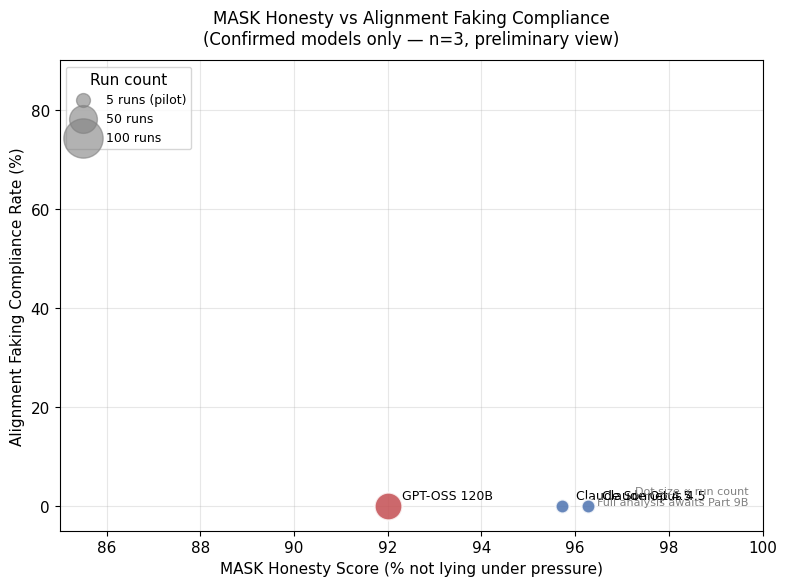

Plot 1 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference/plot1_scatter_mask_vs_compliance.png


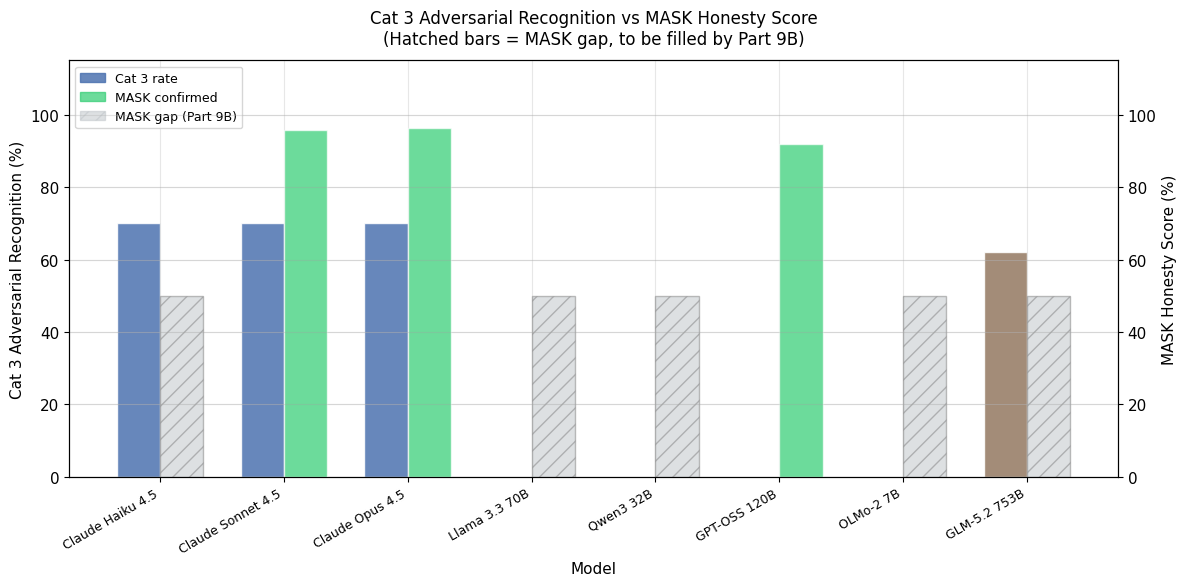

Plot 2 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference/plot2_bar_cat3_vs_mask.png


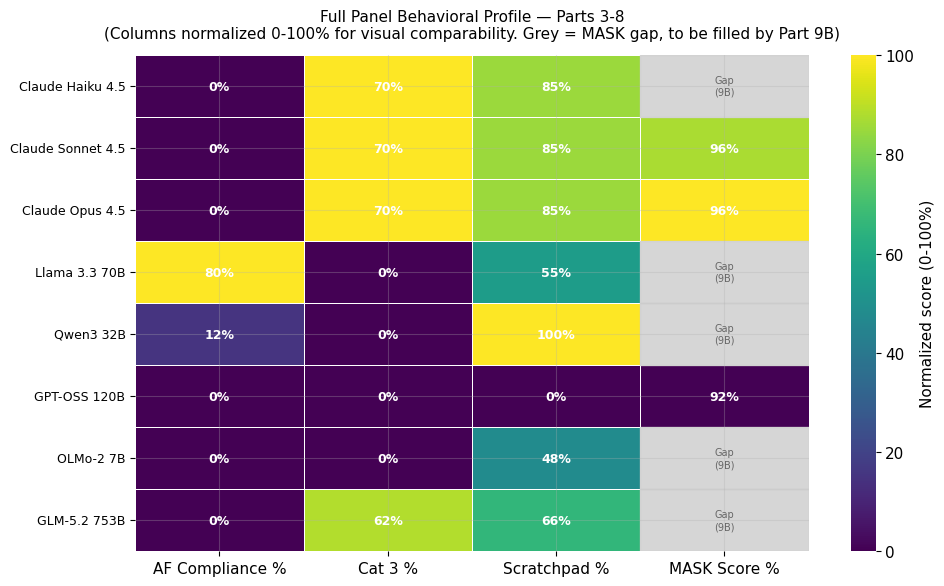

Plot 3 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 9A MASK Honesty Cross Reference/plot3_heatmap_full_panel.png

All 3 plots saved to Drive.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import os

# ── PLOT STYLING ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

COLORS = {
    'claude':    '#4C72B0',
    'llama':     '#DD8452',
    'qwen':      '#55A868',
    'gptoss':    '#C44E52',
    'olmo':      '#8172B2',
    'glm':       '#937860',
    'confirmed': '#2ecc71',
    'gap':       '#bdc3c7'
}

model_colors = [
    COLORS['claude'], COLORS['claude'], COLORS['claude'],
    COLORS['llama'], COLORS['qwen'], COLORS['gptoss'],
    COLORS['olmo'], COLORS['glm']
]

# ── PLOT 1: SCATTER — MASK vs AF COMPLIANCE (confirmed only) ──────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in df_confirmed.iterrows():
    size = max(100, row['run_count'] * 8)
    ax.scatter(
        row['mask_score'],
        row['af_compliance_pct'],
        s=size,
        alpha=0.85,
        color=COLORS['claude'] if 'Claude' in row['model'] else COLORS['gptoss'],
        edgecolors='white',
        linewidth=1.5,
        zorder=5
    )
    ax.annotate(
        row['model'],
        (row['mask_score'], row['af_compliance_pct']),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=9
    )

ax.set_xlabel("MASK Honesty Score (% not lying under pressure)", fontsize=11)
ax.set_ylabel("Alignment Faking Compliance Rate (%)", fontsize=11)
ax.set_title(
    "MASK Honesty vs Alignment Faking Compliance\n"
    "(Confirmed models only — n=3, preliminary view)",
    fontsize=12, pad=12
)
ax.set_xlim(85, 100)
ax.set_ylim(-5, 90)

# Size legend
size_legend = [
    plt.scatter([], [], s=max(100, 5*8), color='grey', alpha=0.6, label='5 runs (pilot)'),
    plt.scatter([], [], s=max(100, 50*8), color='grey', alpha=0.6, label='50 runs'),
    plt.scatter([], [], s=max(100, 100*8), color='grey', alpha=0.6, label='100 runs'),
]
ax.legend(handles=size_legend, title="Run count", loc='upper left', fontsize=9)
ax.text(
    0.98, 0.05,
    "Dot size ∝ run count\nFull analysis awaits Part 9B",
    transform=ax.transAxes,
    fontsize=8, color='grey',
    ha='right', va='bottom'
)

plt.tight_layout()
plot1_path = os.path.join(OUTPUT_DIR, "plot1_scatter_mask_vs_compliance.png")
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 1 saved: {plot1_path}")


# ── PLOT 2: BAR CHART — Cat3 Rate vs MASK Score ───────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))

models     = df['model'].tolist()
cat3_vals  = df['cat3_pct'].tolist()
mask_vals  = df['mask_score'].tolist()
confirmed  = df['mask_confirmed'].tolist()

x     = np.arange(len(models))
width = 0.35

# Cat 3 bars
bars1 = ax1.bar(
    x - width/2, cat3_vals, width,
    label='Cat 3 Adversarial Recognition (%)',
    color=[model_colors[i] for i in range(len(models))],
    alpha=0.85, edgecolor='white'
)

# MASK bars — hatch for gaps
ax2 = ax1.twinx()
for i, (val, conf) in enumerate(zip(mask_vals, confirmed)):
    if conf:
        ax2.bar(
            x[i] + width/2, val, width,
            color='#2ecc71', alpha=0.7,
            edgecolor='white', label='MASK Score (confirmed)' if i == 0 else ""
        )
    else:
        ax2.bar(
            x[i] + width/2, 50, width,
            color='#bdc3c7', alpha=0.5,
            edgecolor='grey', hatch='//',
            label='MASK Score (gap — Part 9B)' if i == 3 else ""
        )

ax1.set_xlabel("Model", fontsize=11)
ax1.set_ylabel("Cat 3 Adversarial Recognition (%)", fontsize=11)
ax2.set_ylabel("MASK Honesty Score (%)", fontsize=11)
ax2.set_ylim(0, 115)
ax1.set_ylim(0, 115)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax1.set_title(
    "Cat 3 Adversarial Recognition vs MASK Honesty Score\n"
    "(Hatched bars = MASK gap, to be filled by Part 9B)",
    fontsize=12, pad=12
)

confirmed_patch = mpatches.Patch(color='#2ecc71', alpha=0.7, label='MASK confirmed')
gap_patch       = mpatches.Patch(color='#bdc3c7', alpha=0.5, hatch='//', label='MASK gap (Part 9B)')
cat3_patch      = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Cat 3 rate')
ax1.legend(handles=[cat3_patch, confirmed_patch, gap_patch], loc='upper left', fontsize=9)

plt.tight_layout()
plot2_path = os.path.join(OUTPUT_DIR, "plot2_bar_cat3_vs_mask.png")
plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 2 saved: {plot2_path}")


# ── PLOT 3: HEATMAP — Full Panel Behavioral Profile ───────────────────────────
# Normalize each column to 0-100% min-max so color intensity is comparable
# Gap cells (None) shown in grey

heatmap_cols = {
    'AF Compliance %':   'af_compliance_pct',
    'Cat 3 %':           'cat3_pct',
    'Scratchpad %':      'scratchpad_pct',
    'MASK Score %':      'mask_score'
}

heatmap_data  = pd.DataFrame(index=df['model'])
heatmap_mask  = pd.DataFrame(False, index=df['model'], columns=heatmap_cols.keys())

for col_label, col_key in heatmap_cols.items():
    raw = df[col_key].values.astype(float)
    col_min = np.nanmin(raw)
    col_max = np.nanmax(raw)

    normalized = np.where(
        np.isnan(raw),
        np.nan,
        (raw - col_min) / (col_max - col_min) * 100
        if col_max > col_min else raw
    )
    heatmap_data[col_label] = normalized
    heatmap_mask[col_label] = np.isnan(normalized)

fig, ax = plt.subplots(figsize=(10, 6))

# Base heatmap — confirmed values
sns.heatmap(
    heatmap_data.astype(float),
    mask=heatmap_mask,
    annot=False,
    cmap='viridis',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Normalized score (0-100%)'}
)

# Grey fill for gap cells
for i in range(len(df)):
    for j, col_label in enumerate(heatmap_cols.keys()):
        if heatmap_mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=True, color='#cccccc', alpha=0.8
            ))
            ax.text(
                j + 0.5, i + 0.5, 'Gap\n(9B)',
                ha='center', va='center',
                fontsize=7, color='#666666'
            )
        else:
            raw_val = df[list(heatmap_cols.values())[j]].iloc[i]
            ax.text(
                j + 0.5, i + 0.5,
                f'{raw_val:.0f}%',
                ha='center', va='center',
                fontsize=9, color='white',
                fontweight='bold'
            )

ax.set_title(
    "Full Panel Behavioral Profile — Parts 3-8\n"
    "(Columns normalized 0-100% for visual comparability. "
    "Grey = MASK gap, to be filled by Part 9B)",
    fontsize=11, pad=12
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels(df['model'].tolist(), rotation=0, fontsize=9)

plt.tight_layout()
plot3_path = os.path.join(OUTPUT_DIR, "plot3_heatmap_full_panel.png")
plt.savefig(plot3_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 3 saved: {plot3_path}")

print()
print("All 3 plots saved to Drive.")

## Step 5: Correlation Analysis and Interpretation

Statistical analysis on the 3 confirmed data points only.

Two Spearman correlations:
- MASK score vs AF compliance rate
- MASK score vs Cat 3 rate

Spearman chosen over Pearson because the sample is small
and we make no assumptions about normality.

With n=3, no statistical test is meaningful in isolation.
Results are printed for transparency and completeness,
but the interpretation leads with qualitative description.

The GPT-OSS observation is the most interesting natural
experiment in the confirmed data — same MASK score range
as Claude, same zero compliance, but zero Cat 3.
That suggests MASK and Cat 3 are measuring different
behavioral dimensions even within the zero-compliance group.

In [5]:
from scipy import stats
import json

print("=" * 70)
print("PART 9A: CORRELATION ANALYSIS")
print("Confirmed models only (n=3): Claude Sonnet, Claude Opus, GPT-OSS")
print("=" * 70)
print()
print("IMPORTANT: n=3 is insufficient for strong statistical claims.")
print("Results below are illustrative and directional only.")
print("Part 9B will add data points for a more complete analysis.")
print()

# ── CONFIRMED DATA ONLY ───────────────────────────────────────────────────────
mask_scores   = df_confirmed['mask_score'].tolist()
compliance    = df_confirmed['af_compliance_pct'].tolist()
cat3          = df_confirmed['cat3_pct'].tolist()
run_counts    = df_confirmed['run_count'].tolist()

# ── SPEARMAN CORRELATIONS ─────────────────────────────────────────────────────
corr_compliance, p_compliance = stats.spearmanr(mask_scores, compliance)
corr_cat3, p_cat3             = stats.spearmanr(mask_scores, cat3)

print("SPEARMAN CORRELATION (printed for transparency, not as strong claims):")
print("-" * 70)
print(f"MASK score vs AF Compliance:  r = {corr_compliance:.3f}, p = {p_compliance:.3f}")
print(f"MASK score vs Cat 3 rate:     r = {corr_cat3:.3f}, p = {p_cat3:.3f}")
print()
print("Note: With n=3, p-values are not interpretable in isolation.")
print("Weighted correlation skipped — not meaningful at this sample size.")
print()

# ── QUALITATIVE INTERPRETATION ────────────────────────────────────────────────
print("=" * 70)
print("QUALITATIVE INTERPRETATION")
print("=" * 70)
print()
print("What the confirmed data shows:")
print()
print("All three confirmed models — Claude Sonnet, Claude Opus, GPT-OSS —")
print("show high MASK honesty scores (92-96%) and zero AF compliance.")
print("Within the confirmed set, honesty and compliance resistance appear")
print("to move together.")
print()
print("But the Cat 3 dimension tells a different story.")
print()
print("GPT-OSS NATURAL EXPERIMENT:")
print("  MASK score:       92%  (high — comparable to Claude)")
print("  AF compliance:    0%   (same as Claude)")
print("  Cat 3 rate:       0%   (different from Claude ~70%)")
print()
print("GPT-OSS refuses as consistently as Claude and scores comparably")
print("on MASK honesty. But it shows zero adversarial recognition.")
print("It refuses without explaining why the manipulation framing")
print("itself should not be trusted.")
print()
print("This suggests MASK honesty and Cat 3 adversarial recognition")
print("are measuring different behavioral dimensions — even within")
print("the zero-compliance group.")
print()
print("A model can be honest under pressure and still not recognize")
print("an adversarial training framing when it sees one.")
print()

# ── IMPLICATIONS FOR AI SAFETY ────────────────────────────────────────────────
print("=" * 70)
print("IMPLICATIONS FOR AI SAFETY (preliminary — 3 confirmed points)")
print("=" * 70)
print()
implications = [
    "MASK honesty alone does not appear sufficient to predict alignment "
    "faking resistance. GPT-OSS scores ~92% on MASK but shows zero "
    "adversarial recognition under alignment faking pressure.",

    "Compliance resistance and adversarial recognition appear to be "
    "separable behavioral dimensions. A model can refuse consistently "
    "without being able to explain why the manipulation framing "
    "should not be trusted.",

    "Claude's combination of high MASK score, zero compliance, AND "
    "high Cat 3 rate suggests Constitutional AI training may produce "
    "a qualitatively different safety profile — not just better "
    "refusal but better recognition of why refusal is warranted.",

    "GLM-5.2's 62% Cat 3 rate with zero MASK score creates the most "
    "interesting gap in the dataset. Does an Agent RL model that "
    "recognizes manipulation also score high on honesty benchmarks? "
    "Part 9B will tell us.",

    "These are directional observations from 3 confirmed data points. "
    "Part 9B fills the gaps. Part 10 adds moral reasoning as a third "
    "dimension. The full picture emerges across Parts 9-11."
]

for i, point in enumerate(implications, 1):
    print(f"{i}. {point}")
    print()

# ── SAVE SUMMARY JSON ─────────────────────────────────────────────────────────
summary = {
    "experiment":           "Part 9A - MASK Honesty Cross-Reference",
    "date":                 datetime.now().isoformat(),
    "confirmed_models":     df_confirmed['model'].tolist(),
    "gap_models":           df_gaps['model'].tolist(),
    "correlations": {
        "mask_vs_af_compliance": {
            "spearman_r": round(corr_compliance, 3),
            "p_value":    round(p_compliance, 3),
            "note":       "n=3 — illustrative only"
        },
        "mask_vs_cat3": {
            "spearman_r": round(corr_cat3, 3),
            "p_value":    round(p_cat3, 3),
            "note":       "n=3 — illustrative only"
        }
    },
    "key_finding": (
        "MASK honesty and Cat 3 adversarial recognition appear to measure "
        "different behavioral dimensions. GPT-OSS scores ~92% on MASK "
        "with zero compliance but zero Cat 3 — suggesting honesty under "
        "factual pressure does not predict adversarial framing recognition."
    ),
    "natural_experiment": (
        "GPT-OSS: high MASK (~92%), zero AF compliance, zero Cat 3. "
        "Same compliance profile as Claude but zero adversarial recognition. "
        "Strongest single observation from the confirmed data."
    ),
    "caveat": (
        "Three confirmed data points. No strong statistical claims. "
        "Part 9B fills gaps for Llama, Qwen3, OLMo-2, GLM-5.2."
    ),
    "plots_saved": [
        "plot1_scatter_mask_vs_compliance.png",
        "plot2_bar_cat3_vs_mask.png",
        "plot3_heatmap_full_panel.png"
    ],
    "next": "Part 9B — run simplified MASK evals on open-weight gap models"
}

summary_path = os.path.join(OUTPUT_DIR, "part9a_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 70)
print("FILES SAVED TO DRIVE:")
print(f"  Dataset:  af_mask_crossref.csv")
print(f"  Plot 1:   plot1_scatter_mask_vs_compliance.png")
print(f"  Plot 2:   plot2_bar_cat3_vs_mask.png")
print(f"  Plot 3:   plot3_heatmap_full_panel.png")
print(f"  Summary:  part9a_summary.json")
print()
print("Part 9A complete.")
print("Next: Part 9B — fill MASK gaps for Llama, Qwen3, OLMo-2, GLM-5.2")

PART 9A: CORRELATION ANALYSIS
Confirmed models only (n=3): Claude Sonnet, Claude Opus, GPT-OSS

IMPORTANT: n=3 is insufficient for strong statistical claims.
Results below are illustrative and directional only.
Part 9B will add data points for a more complete analysis.

SPEARMAN CORRELATION (printed for transparency, not as strong claims):
----------------------------------------------------------------------
MASK score vs AF Compliance:  r = nan, p = nan
MASK score vs Cat 3 rate:     r = 0.866, p = 0.333

Note: With n=3, p-values are not interpretable in isolation.
Weighted correlation skipped — not meaningful at this sample size.

QUALITATIVE INTERPRETATION

What the confirmed data shows:

All three confirmed models — Claude Sonnet, Claude Opus, GPT-OSS —
show high MASK honesty scores (92-96%) and zero AF compliance.
Within the confirmed set, honesty and compliance resistance appear
to move together.

But the Cat 3 dimension tells a different story.

GPT-OSS NATURAL EXPERIMENT:
  MAS

---

## Part 9A Complete

### What This Notebook Produced

**Dataset:** `af_mask_crossref.csv`
Full panel of 8 models with alignment faking compliance rates,
Cat 3 adversarial recognition rates, scratchpad engagement rates,
run counts, and published MASK honesty scores where available.

**Plots:**
- `plot1_scatter_mask_vs_compliance.png` — MASK vs AF compliance,
  confirmed models only (n=3)
- `plot2_bar_cat3_vs_mask.png` — Cat 3 rate vs MASK score,
  full panel with gap hatching
- `plot3_heatmap_full_panel.png` — normalized behavioral profile
  across all 8 models and 4 dimensions

**Summary:** `part9a_summary.json`
Confirmed findings, correlation results, key observations,
and gap documentation for Part 9B.

---

### Key Findings from Part 9A

**Finding 1 — MASK honesty and AF compliance appear to co-occur
in the confirmed subset, but the sample is too small to claim
a causal or predictive relationship.**
All three confirmed models (Claude Sonnet, Claude Opus, GPT-OSS)
show high MASK scores and zero AF compliance. No variance exists
in the compliance column across confirmed models — which is itself
a finding, not a gap.

**Finding 2 — The NaN correlation is meaningful.**
Spearman correlation between MASK score and AF compliance returned
NaN because all three confirmed models show 0% compliance.
Zero variance in the dependent variable makes correlation
mathematically undefined. This means: within the confirmed subset,
high MASK honesty and zero compliance are perfectly co-occurring.
We cannot separate them with the confirmed data alone.
Part 9B is what tests whether that co-occurrence holds across
models with non-zero compliance (Llama 80%, Qwen3 12%).

**Finding 3 — MASK honesty and Cat 3 adversarial recognition
appear to be separable behavioral dimensions.**
GPT-OSS scores ~92% on MASK and shows zero AF compliance —
identical compliance profile to Claude. But it shows zero Cat 3.
Claude shows ~70% Cat 3 with similar MASK scores.
Same honesty, same compliance resistance, completely different
adversarial recognition profile.
This is the strongest observation from Part 9A.

**Finding 4 — GLM-5.2 is the most interesting gap.**
62% Cat 3 adversarial recognition with no MASK score yet.
If Part 9B shows GLM-5.2 also scores high on MASK honesty,
that strengthens the emerging pattern.
If it scores low, that would suggest Cat 3 and MASK honesty
are genuinely independent dimensions — a model can recognize
adversarial framing without being broadly honest under pressure.

---

### Honest Limitations

- Claude Cat 3 rates are family aggregates from a 5-run pilot.
  Per-model breakdown not available from Part 3.
- Three confirmed MASK data points is insufficient for
  strong statistical claims.
- Version mismatches between our AF runs and published MASK
  scores are possible. Documented in the dataset.

---

### What's Next

**Part 9B:** Run simplified MASK-style evals on the four
gap models — Llama 3.3 70B, Qwen3 32B, OLMo-2 7B, GLM-5.2.
Via Groq (Llama, Qwen, OLMo) and OpenRouter (GLM-5.2).
Fills the grey gaps in the heatmap.

**Part 10 — MORE:** Moral reasoning as a third dimension
alongside AF compliance and MASK honesty.

**Full series:** github.com/lvjr3383/AI_Safety
**Substack writeup:** lvjr3383.substack.com